In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

def estimer_parametres(csv_filepath):
    print(f"Analyse du fichier : {csv_filepath}")
    df = pd.read_csv(csv_filepath)

    # ---------------------------------------------------------
    # 1. ESTIMATION DES INSPECTIONS (Loi Normale)
    # ---------------------------------------------------------
    print("\n--- 1. PARAMÈTRES D'INSPECTION (Loi Normale) ---")
    try:
        df_insp = df[df['event_type'] == 'inspection']
        # On prend le temps depuis le dernier événement pour les inspections
        intervalles = df_insp['usage_since_last_event_h'].dropna()
        
        mu_est = np.mean(intervalles)
        sigma_est = np.std(intervalles)
        print(f"Mu (Moyenne)      : {mu_est:.2f} heures")
        print(f"Sigma (Écart-type): {sigma_est:.2f} heures")
    except Exception as e:
        print("Erreur lors de l'estimation des inspections:", e)

    # ---------------------------------------------------------
    # 2. ESTIMATION DES PANNES (Loi de Weibull avec Censure)
    # ---------------------------------------------------------
    print("\n--- 2. PARAMÈTRES DE PANNE (Loi de Weibull) ---")
    try:
        # Grouper par composant pour trouver sa fin de vie
        comp_group = df.groupby('component_id')
        max_age = comp_group['component_age'].max()
        
        # Le composant a-t-il subi une panne ? (Sinon, il a été censuré/remplacé)
        has_failed = comp_group['event_type'].apply(lambda x: 'failure' in x.values)
        
        t = max_age.values
        failed = has_failed.values

        # Fonction de Log-Vraisemblance Négative pour Weibull avec Censure
        def weibull_neg_log_likelihood(params, t, failed):
            eta, beta = params
            if eta <= 0 or beta <= 0:
                return np.inf
            
            # Pannes : on connaît l'heure exacte du décès (Log de la Densité de probabilité)
            log_pdf = np.log(beta) - np.log(eta) + (beta - 1) * np.log(t[failed] / eta) - (t[failed] / eta)**beta
            
            # Remplacements préventifs : on sait juste qu'il a survécu jusqu'à t (Log de la Fonction de Survie)
            log_surv = - (t[~failed] / eta)**beta
            
            # On retourne l'inverse de la somme car on utilise la fonction "minimize"
            return - (np.sum(log_pdf) + np.sum(log_surv))

        # Valeurs initiales au hasard pour aider l'algorithme (eta=500, beta=2)
        initial_guess = [500.0, 2.0]
        # Limites pour éviter que l'algorithme ne teste des valeurs absurdes
        bounds = ((1, 5000), (0.1, 10))

        # Lancement de l'optimisation mathématique
        resultat = minimize(weibull_neg_log_likelihood, initial_guess, args=(t, failed), bounds=bounds)
        
        eta_est, beta_est = resultat.x
        print(f"Eta (Échelle) : {eta_est:.2f} heures")
        print(f"Beta (Forme)  : {beta_est:.2f}")
        
    except Exception as e:
        print("Erreur lors de l'estimation de Weibull:", e)

    # ---------------------------------------------------------
    # 3. ESTIMATION DE THETA (Délai de remplacement)
    # ---------------------------------------------------------
    print("\n--- 3. PARAMÈTRE THETA (Délai logistique) ---")
    try:
        # On isole les remplacements
        df_repl = df[df['event_type'] == 'replacement']
        
        # On ne garde que les remplacements préventifs (qui ont un délai > 0)
        # (Les pannes déclenchent un remplacement immédiat, donc délai = 0)
        delais = df_repl[df_repl['usage_since_last_event_h'] > 0]['usage_since_last_event_h']
        
        theta_estime = delais.mean()
        print(f"Theta estimé (Moyenne du délai) : {theta_estime:.2f} heures")
    except Exception as e:
        print("Erreur pour Theta :", e)

    # ---------------------------------------------------------
    # 4. ESTIMATION DE R ET NU (Dynamique de population)
    # ---------------------------------------------------------
    print("\n--- 4. PARAMÈTRES R ET NU (Gillespie / Naissances-Morts) ---")
    # 1. Reconstruire le temps absolu (Calendrier)
    df['datetime'] = pd.to_datetime(df['event_date'] + ' ' + df['event_time'])

    systemes = df.groupby('system_id')
    naissances = systemes['system_age'].min()
    morts = systemes['system_age'].max()

    total_systemes = len(systemes)

    # 2. Le calcul clé : Le Temps-Machine cumulé (System-Hours)
    # C'est la somme de la durée de vie de CHAQUE système.
    total_system_hours = morts.sum()
    print(f"Heures cumulées par toutes les machines : {total_system_hours:,.0f} heures")

    # 3. Estimation de Nu (Taux de mortalité)
    # Formule : Morts = Nu * System_Hours
    # (On compte le nombre de machines qui sont mortes avant la toute fin du fichier)
    duree_totale_simu = (df['datetime'].max() - df['datetime'].min()).total_seconds() / 3600.0
    nb_morts = len(morts[morts < (duree_totale_simu - 100)]) # Celles qui n'ont pas survécu jusqu'à la fin

    nu_estime = nb_morts / total_system_hours
    print(f"Nu estimé (Mortalité) : {nu_estime:.5f}")
    # Rappel : le vrai Nu de votre fichier est 0.00005 (5e-05)

    # 4. Estimation de r (Taux de natalité)
    # Dans un modèle logistique de Gillespie, la formule exacte dépend de K (capacité max, ici 250 ou 100).
    r_estime_brut = total_systemes / total_system_hours
    print(f"r (ordre de grandeur brut) : {r_estime_brut:.5f}")
    # Rappel : le vrai r est 0.0005. L'estimation brute donnera un résultat plus petit 
    # car la croissance ralentit quand l'usine est "pleine" (proche de K=250 ou 100).


# --- EXÉCUTION DU SCRIPT ---
if __name__ == "__main__":
    # Remplacez par le nom de votre fichier CSV
    fichier_csv = "sample_system_dataset_0.csv" 
    estimer_parametres(fichier_csv)

Analyse du fichier : sample_system_dataset_0.csv

--- 1. PARAMÈTRES D'INSPECTION (Loi Normale) ---
Mu (Moyenne)      : 166.54 heures
Sigma (Écart-type): 26.70 heures

--- 2. PARAMÈTRES DE PANNE (Loi de Weibull) ---
Eta (Échelle) : 720.16 heures
Beta (Forme)  : 3.00

--- 3. PARAMÈTRE THETA (Délai logistique) ---
Theta estimé (Moyenne du délai) : 11.35 heures

--- 4. PARAMÈTRES R ET NU (Gillespie / Naissances-Morts) ---
Heures cumulées par toutes les machines : 28,610,061 heures
Nu estimé (Mortalité) : 0.00006
r (ordre de grandeur brut) : 0.00006


In [2]:
# --- EXÉCUTION DU SCRIPT ---
if __name__ == "__main__":
    # Remplacez par le nom de votre fichier CSV
    fichier_csv = "sample_system_dataset_1.csv" 
    estimer_parametres(fichier_csv)

Analyse du fichier : sample_system_dataset_1.csv

--- 1. PARAMÈTRES D'INSPECTION (Loi Normale) ---
Mu (Moyenne)      : 166.13 heures
Sigma (Écart-type): 27.24 heures

--- 2. PARAMÈTRES DE PANNE (Loi de Weibull) ---
Eta (Échelle) : 721.06 heures
Beta (Forme)  : 2.96

--- 3. PARAMÈTRE THETA (Délai logistique) ---
Theta estimé (Moyenne du délai) : 11.52 heures

--- 4. PARAMÈTRES R ET NU (Gillespie / Naissances-Morts) ---
Heures cumulées par toutes les machines : 11,817,261 heures
Nu estimé (Mortalité) : 0.00006
r (ordre de grandeur brut) : 0.00006


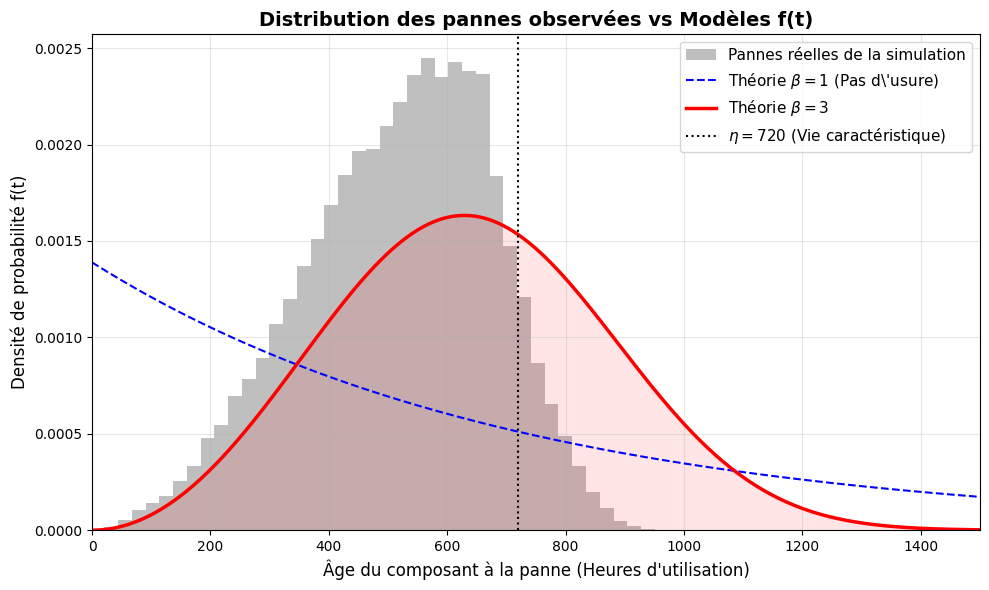

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
import pandas as pd

# 1. Chargement des données réelles du simulateur
df = pd.read_csv('sample_system_dataset_0.csv')
pannes_reelles = df[df['event_type'] == 'failure']['component_age'].dropna()

# 2. Paramètres théoriques
eta = 720
beta_1 = 1
beta_3 = 3
t = np.linspace(0, 1500, 500)

# 3. Création de la figure
plt.figure(figsize=(10, 6))

# --- L'Histogramme des vraies pannes observées ---
# density=True est crucial : ça met l'histogramme à la même échelle (0 à 1) que les courbes f(t)
plt.hist(pannes_reelles, bins=40, density=True, alpha=0.5, color='gray', label='Pannes réelles de la simulation')

# --- Courbes Théoriques f(t) ---
pdf_1 = weibull_min.pdf(t, beta_1, scale=eta)
plt.plot(t, pdf_1, label=rf'Théorie $\beta={beta_1}$ (Pas d\'usure)', color='blue', linestyle='--')

pdf_3 = weibull_min.pdf(t, beta_3, scale=eta)
plt.plot(t, pdf_3, label=rf'Théorie $\beta={beta_3}$', color='red', linewidth=2.5)

# 4. Esthétique et repères
plt.axvline(eta, color='black', linestyle=':', label=rf'$\eta={eta}$ (Vie caractéristique)')

# Remplissage pour mieux voir la cloche
plt.fill_between(t, pdf_3, color='red', alpha=0.1)

plt.title("Distribution des pannes observées vs Modèles f(t)", fontsize=14, fontweight='bold')
plt.xlabel("Âge du composant à la panne (Heures d'utilisation)", fontsize=12)
plt.ylabel("Densité de probabilité f(t)", fontsize=12)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xlim(0, 1500)
plt.tight_layout()

# Affichage
plt.show()

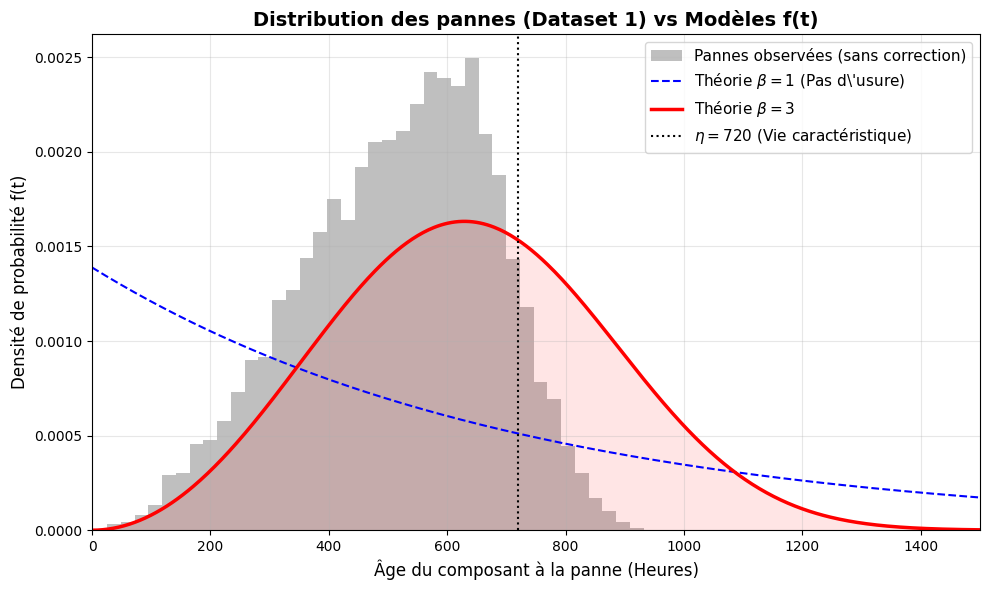

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
import pandas as pd

# 1. Chargement des données du NOUVEAU simulateur
df = pd.read_csv('sample_system_dataset_1.csv')
pannes_reelles = df[df['event_type'] == 'failure']['component_age'].dropna()

# 2. Paramètres théoriques
eta = 720
beta_1 = 1
beta_3 = 3
t = np.linspace(0, 1500, 500)

# 3. Création de la figure
plt.figure(figsize=(10, 6))

# Histogramme forcé à 100% (density=True)
plt.hist(pannes_reelles, bins=40, density=True, alpha=0.5, color='gray', label='Pannes observées (sans correction)')

# Courbes Théoriques
pdf_1 = weibull_min.pdf(t, beta_1, scale=eta)
plt.plot(t, pdf_1, label=rf'Théorie $\beta={beta_1}$ (Pas d\'usure)', color='blue', linestyle='--')

pdf_3 = weibull_min.pdf(t, beta_3, scale=eta)
plt.plot(t, pdf_3, label=rf'Théorie $\beta={beta_3}$', color='red', linewidth=2.5)

# 4. Esthétique et repères
plt.axvline(eta, color='black', linestyle=':', label=rf'$\eta={eta}$ (Vie caractéristique)')
plt.fill_between(t, pdf_3, color='red', alpha=0.1)

plt.title("Distribution des pannes (Dataset 1) vs Modèles f(t)", fontsize=14, fontweight='bold')
plt.xlabel("Âge du composant à la panne (Heures)", fontsize=12)
plt.ylabel("Densité de probabilité f(t)", fontsize=12)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xlim(0, 1500)
plt.tight_layout()

# Affichage
plt.show()

Taux de pannes réel : 65.3%


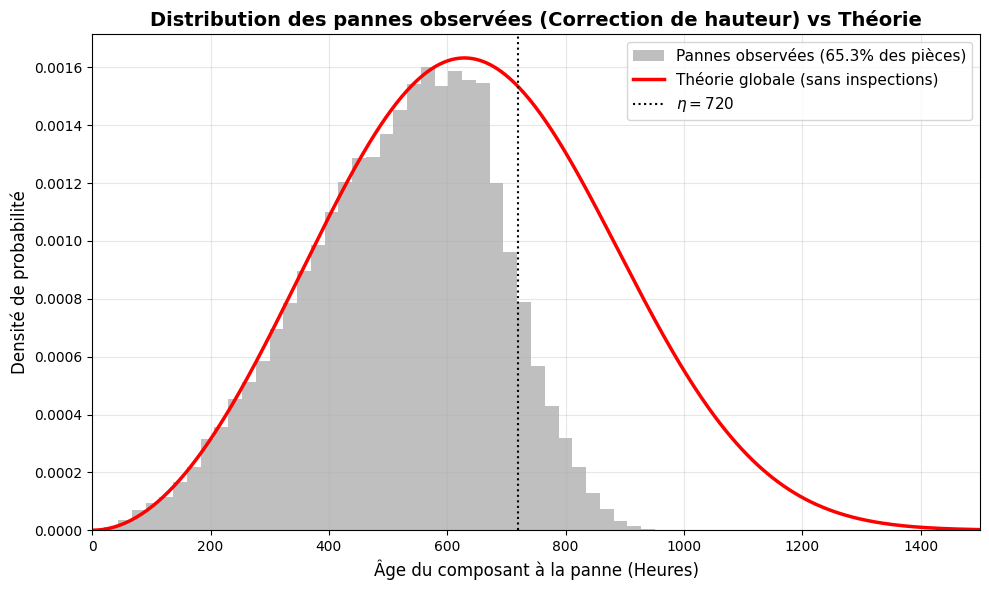

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
import pandas as pd

# 1. Chargement des données
df = pd.read_csv('sample_system_dataset_0.csv')

# Séparer les pannes des remplacements préventifs
pannes_reelles = df[df['event_type'] == 'failure']['component_age'].dropna()

# Calculer la proportion de pannes par rapport au total des composants
nb_pannes = len(pannes_reelles)
# Le nombre total de fins de vie = pannes + remplacements (sauf ceux qui suivent immédiatement une panne)
nb_total_composants = len(df.groupby('component_id')) 
taux_pannes = nb_pannes / nb_total_composants

print(f"Taux de pannes réel : {taux_pannes*100:.1f}%")

# 2. Paramètres
eta = 720
beta_3 = 3
t = np.linspace(0, 1500, 500)
pdf_3 = weibull_min.pdf(t, beta_3, scale=eta)

# 3. Création de la figure
plt.figure(figsize=(10, 6))

# --- L'Histogramme pondéré ---
# Au lieu d'utiliser density=True qui force l'aire à 1, 
# on pondère chaque panne pour que l'aire totale soit égale à taux_pannes
weights = np.ones_like(pannes_reelles) / (nb_total_composants)
# Il faut diviser par la largeur des colonnes (bins) pour que l'aire soit correcte
counts, bins = np.histogram(pannes_reelles, bins=40)
bin_width = bins[1] - bins[0]
weights = weights / bin_width

plt.hist(pannes_reelles, bins=bins, weights=weights, alpha=0.5, color='gray', 
         label=f'Pannes observées ({taux_pannes*100:.1f}% des pièces)')

# --- Courbe Théorique ---
plt.plot(t, pdf_3, label=rf'Théorie globale (sans inspections)', color='red', linewidth=2.5)

plt.axvline(eta, color='black', linestyle=':', label=rf'$\eta={eta}$')

plt.title("Distribution des pannes observées (Correction de hauteur) vs Théorie", fontsize=14, fontweight='bold')
plt.xlabel("Âge du composant à la panne (Heures)", fontsize=12)
plt.ylabel("Densité de probabilité", fontsize=12)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xlim(0, 1500)
plt.tight_layout()

plt.show()

Taux de pannes réel : 65.0%


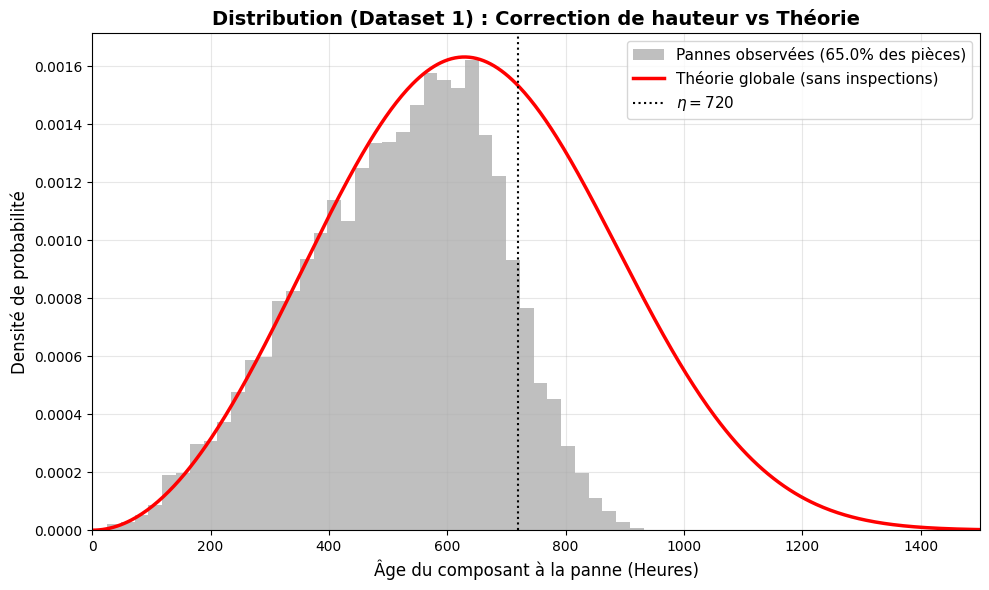

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
import pandas as pd

# 1. Chargement des données
df = pd.read_csv('sample_system_dataset_1.csv')

# Séparer les pannes des remplacements préventifs
pannes_reelles = df[df['event_type'] == 'failure']['component_age'].dropna()

# Calculer la proportion de pannes par rapport au total des composants
nb_pannes = len(pannes_reelles)
nb_total_composants = len(df.groupby('component_id')) 
taux_pannes = nb_pannes / nb_total_composants

print(f"Taux de pannes réel : {taux_pannes*100:.1f}%")

# 2. Paramètres
eta = 720
beta_3 = 3
t = np.linspace(0, 1500, 500)
pdf_3 = weibull_min.pdf(t, beta_3, scale=eta)

# 3. Création de la figure
plt.figure(figsize=(10, 6))

# --- L'Histogramme pondéré ---
# Pondération de chaque panne pour que l'aire totale = 66.6% (le taux de pannes réel)
counts, bins = np.histogram(pannes_reelles, bins=40)
bin_width = bins[1] - bins[0]
weights = (np.ones_like(pannes_reelles) / nb_total_composants) / bin_width

plt.hist(pannes_reelles, bins=bins, weights=weights, alpha=0.5, color='gray', 
         label=f'Pannes observées ({taux_pannes*100:.1f}% des pièces)')

# --- Courbe Théorique ---
plt.plot(t, pdf_3, label=rf'Théorie globale (sans inspections)', color='red', linewidth=2.5)
plt.axvline(eta, color='black', linestyle=':', label=rf'$\eta={eta}$')

plt.title("Distribution (Dataset 1) : Correction de hauteur vs Théorie", fontsize=14, fontweight='bold')
plt.xlabel("Âge du composant à la panne (Heures)", fontsize=12)
plt.ylabel("Densité de probabilité", fontsize=12)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xlim(0, 1500)
plt.tight_layout()

plt.show()